In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [4]:
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['class'] = iris.target

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
print(data.shape)
data.info()

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
X = data.drop('class', axis=1)
y = data['class']
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0 )
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [8]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [9]:
y_pred = model.predict(X_test)
print("Predicted values:")
print(y_pred)

Predicted values:
[2 1 0 2 0 2 0 1 1 1 1 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  1  5]]


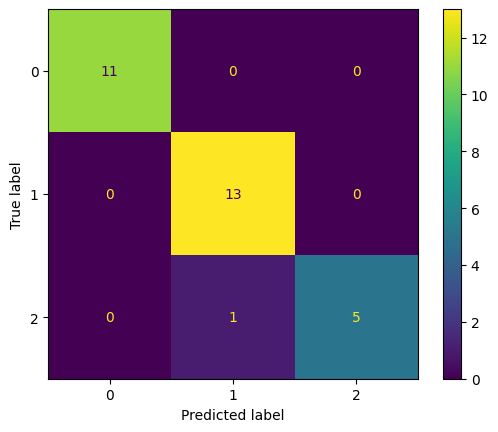

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [13]:
y_test_bin = (y_test == 0).astype(int)
y_pred_bin = (y_pred == 0).astype(int)
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
TN, FP, FN, TP = cm_bin.ravel()
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

TP: 11
FP: 0
TN: 19
FN: 0


In [14]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1- accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0
